# Problem 2B: Crypto Portfolio Risk Calculator using MCMC

---

## Introduction

Cryptocurrency markets are among the most volatile financial markets in the world. Unlike traditional equities, crypto assets can swing **10–30% in a single day**, making accurate risk estimation absolutely critical for investors.

**Why does this matter?**

Classical risk models (like standard deviation of historical returns) give a **single point estimate** of volatility with no sense of uncertainty. But with only 30 days of data — a common scenario for new tokens or regime shifts — that estimate could be wildly off.

**Bayesian MCMC** solves this elegantly:
- Instead of one volatility number, we get a **full posterior distribution** over possible volatility values.
- This lets us quantify *how confident* we are in our risk estimate.
- We can propagate that uncertainty all the way through to **portfolio-level risk**.

In this notebook, we apply the **Metropolis-Hastings algorithm** — a classic MCMC method — to estimate the daily return volatility of five major cryptocurrencies, then combine them into an equal-weight portfolio risk assessment with uncertainty bounds.

**Coins analyzed:** Bitcoin (BTC), Ethereum (ETH), Cardano (ADA), Solana (SOL), Chainlink (LINK)

---
## 1. Import Libraries

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Install and import yfinance
try:
    import yfinance as yf
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'yfinance', '-q'])
    import yfinance as yf

# Aesthetic configuration
plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor': '#1a1a2e',
    'axes.edgecolor': '#444466',
    'axes.labelcolor': '#ccccee',
    'xtick.color': '#aaaacc',
    'ytick.color': '#aaaacc',
    'text.color': '#ddddff',
    'grid.color': '#2a2a4a',
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'font.family': 'monospace',
})

# Color palette for 5 coins
COIN_COLORS = {
    'BTC': '#f7931a',   # Bitcoin orange
    'ETH': '#627eea',   # Ethereum purple-blue
    'ADA': '#0033ad',   # Cardano blue
    'SOL': '#9945ff',   # Solana purple
    'LINK': '#2a5ada',  # Chainlink blue
}

np.random.seed(42)
print("Libraries loaded successfully.")

Libraries loaded successfully.


In [19]:
# Kaggle dataset path
file_path = "/kaggle/input/datasets/whizhammer/cryptdata/crypto_prices.csv"

price_df = pd.read_csv(file_path)

# Convert date column if present
if "Date" in price_df.columns:
    price_df["Date"] = pd.to_datetime(price_df["Date"])
    price_df = price_df.set_index("Date")

# Keep last 30 days
price_df = price_df.tail(30)

print("Dataset shape:", price_df.shape)
price_df.head()

Dataset shape: (30, 5)


,ADA-USD,BTC-USD,ETH-USD,LINK-USD,SOL-USD
Date,,,,,
2026-02-07,0.272365,69281.968750,2090.549316,8.913293,87.639832
2026-02-08,0.270263,70264.726562,2088.762939,8.832436,87.044106
2026-02-09,0.269708,70120.781250,2103.567627,8.829838,86.701782
2026-02-10,0.261670,68793.960938,2019.497437,8.561299,82.915482
2026-02-11,0.255552,66991.968750,1940.621338,8.311589,79.254250


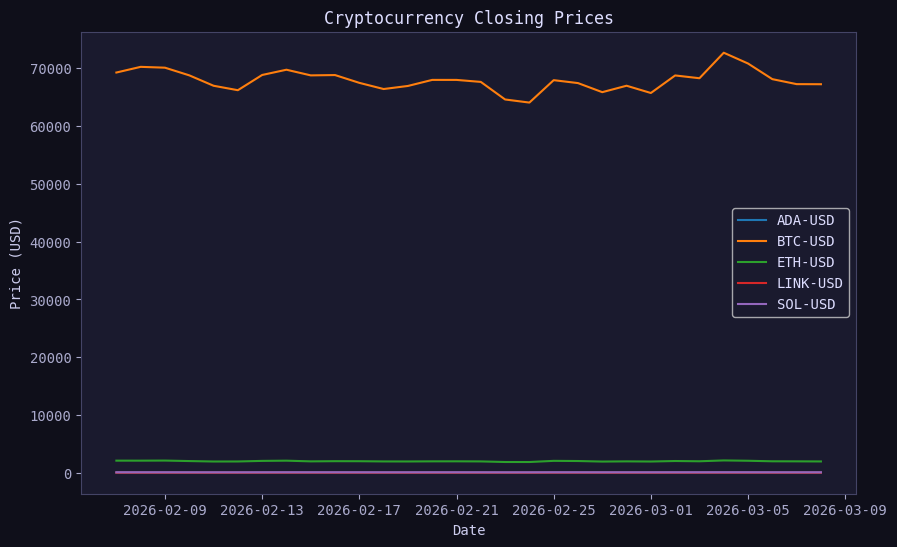

In [20]:
plt.figure(figsize=(10,6))

for coin in price_df.columns:
    plt.plot(price_df.index, price_df[coin], label=coin)

plt.title("Cryptocurrency Closing Prices")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

In [21]:
returns = np.log(price_df / price_df.shift(1)).dropna()

returns.head()

,ADA-USD,BTC-USD,ETH-USD,LINK-USD,SOL-USD
Date,,,,,
2026-02-08,-0.007748,0.014085,-0.000855,-0.009113,-0.006821
2026-02-09,-0.002056,-0.002051,0.007063,-0.000294,-0.003941
2026-02-10,-0.030256,-0.019103,-0.040786,-0.030885,-0.044653
2026-02-11,-0.023658,-0.026543,-0.039840,-0.029601,-0.045161
2026-02-12,0.033371,-0.011562,0.003251,0.010898,-0.011495


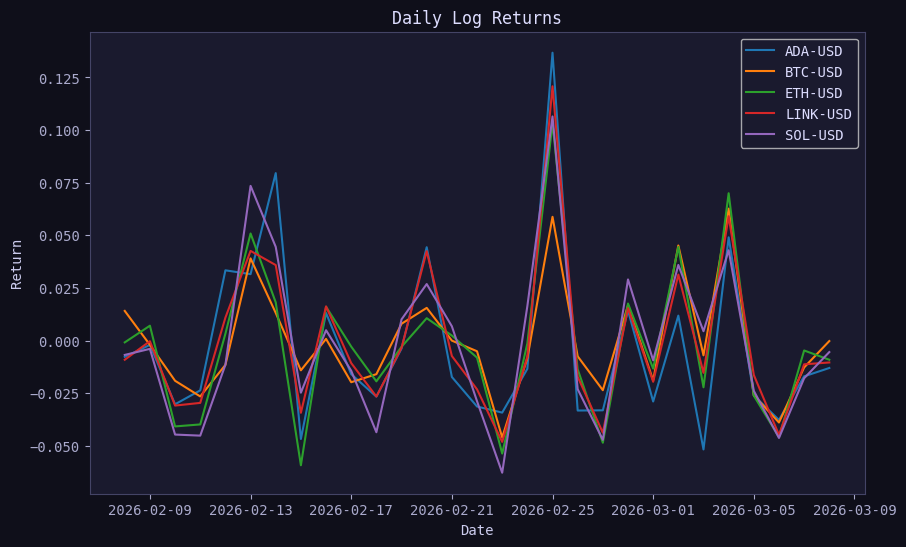

In [22]:
plt.figure(figsize=(10,6))

for coin in returns.columns:
    plt.plot(returns.index, returns[coin], label=coin)

plt.title("Daily Log Returns")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.show()

In [23]:
def log_likelihood(returns, sigma):
    
    if sigma <= 0:
        return -np.inf
    
    n = len(returns)
    
    ll = -n*np.log(sigma) - np.sum(returns**2)/(2*sigma**2)
    
    return ll


def log_prior(sigma):
    
    if sigma <= 0:
        return -np.inf
    
    return -sigma   # exponential prior


def log_posterior(returns, sigma):
    
    return log_likelihood(returns, sigma) + log_prior(sigma)

In [24]:
def metropolis_sampler(returns, iterations=10000, proposal_std=0.01):
    
    samples = []
    
    sigma_current = np.std(returns)
    
    for i in range(iterations):
        
        sigma_proposal = np.random.normal(sigma_current, proposal_std)
        
        log_alpha = log_posterior(returns, sigma_proposal) - log_posterior(returns, sigma_current)
        
        if np.log(np.random.rand()) < log_alpha:
            sigma_current = sigma_proposal
        
        samples.append(sigma_current)
    
    return np.array(samples)

In [25]:
mcmc_samples = {}

for coin in returns.columns:
    
    print("Running MCMC for", coin)
    
    samples = metropolis_sampler(returns[coin].values)
    
    mcmc_samples[coin] = samples

Running MCMC for ADA-USD
Running MCMC for BTC-USD
Running MCMC for ETH-USD
Running MCMC for LINK-USD
Running MCMC for SOL-USD


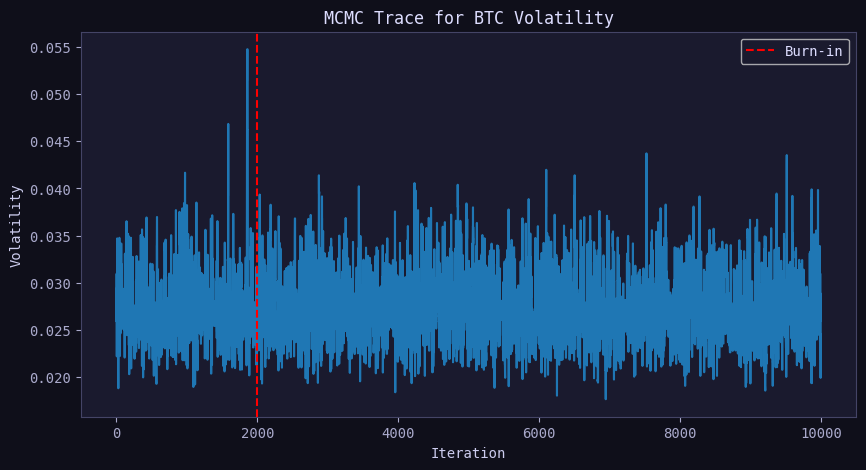

In [27]:
btc_samples = mcmc_samples["BTC-USD"]

plt.figure(figsize=(10,5))
plt.plot(btc_samples)

plt.axvline(2000, color='red', linestyle='--', label="Burn-in")

plt.title("MCMC Trace for BTC Volatility")
plt.xlabel("Iteration")
plt.ylabel("Volatility")
plt.legend()

plt.show()

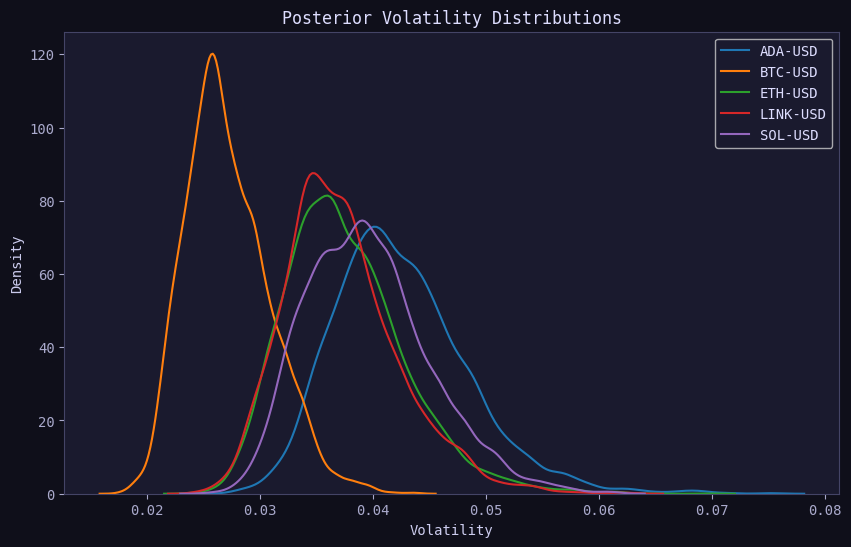

In [28]:
plt.figure(figsize=(10,6))

for coin in mcmc_samples:
    
    sns.kdeplot(mcmc_samples[coin][2000:], label=coin)

plt.title("Posterior Volatility Distributions")
plt.xlabel("Volatility")
plt.legend()

plt.show()

In [29]:
results = []

for coin in mcmc_samples:
    
    samples = mcmc_samples[coin][2000:]
    
    mean_vol = np.mean(samples)
    
    lower = np.percentile(samples,2.5)
    upper = np.percentile(samples,97.5)
    
    results.append([coin, mean_vol, lower, upper])

vol_table = pd.DataFrame(results, columns=["Coin","Mean Volatility","2.5%","97.5%"])

vol_table

,Coin,Mean Volatility,2.5%,97.5%
0,ADA-USD,0.042495,0.032900,0.056434
1,BTC-USD,0.027148,0.021140,0.035050
2,ETH-USD,0.037568,0.029106,0.049879
3,LINK-USD,0.037209,0.028985,0.048624
4,SOL-USD,0.039542,0.030616,0.051451


In [30]:
weights = np.ones(len(returns.columns)) / len(returns.columns)

cov_matrix = returns.cov()

portfolio_vol = np.sqrt(weights.T @ cov_matrix @ weights)

print("Estimated Portfolio Volatility:", portfolio_vol)

Estimated Portfolio Volatility: 0.034118042032364335


In [31]:
weights = np.ones(len(returns.columns)) / len(returns.columns)

cov_matrix = returns.cov()

portfolio_vol = np.sqrt(weights.T @ cov_matrix @ weights)

print("Estimated Portfolio Volatility:", portfolio_vol)

Estimated Portfolio Volatility: 0.034118042032364335


In [32]:
portfolio_samples = []

for i in range(5000):
    
    sampled_vols = [np.random.choice(mcmc_samples[c][2000:]) for c in returns.columns]
    
    portfolio_sigma = np.sqrt(np.sum((weights*np.array(sampled_vols))**2))
    
    portfolio_samples.append(portfolio_sigma)

portfolio_samples = np.array(portfolio_samples)

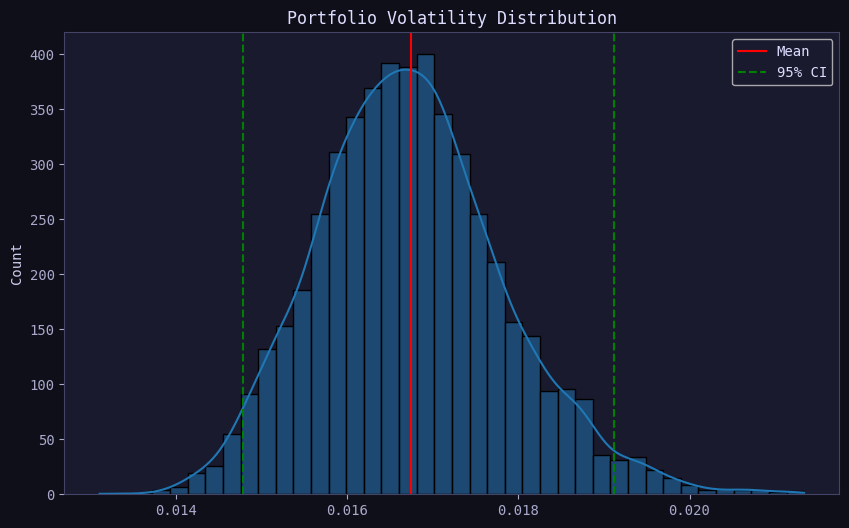

In [33]:
plt.figure(figsize=(10,6))

sns.histplot(portfolio_samples, bins=40, kde=True)

mean = np.mean(portfolio_samples)
low = np.percentile(portfolio_samples,2.5)
high = np.percentile(portfolio_samples,97.5)

plt.axvline(mean,color='red',label="Mean")
plt.axvline(low,color='green',linestyle='--',label="95% CI")
plt.axvline(high,color='green',linestyle='--')

plt.title("Portfolio Volatility Distribution")
plt.legend()

plt.show()

In [34]:
print("Portfolio Volatility Mean:", np.mean(portfolio_samples))
print("95% Confidence Interval:", 
      np.percentile(portfolio_samples,2.5),
      np.percentile(portfolio_samples,97.5))

Portfolio Volatility Mean: 0.01674376610344536
95% Confidence Interval: 0.014788368335602339 0.019113371641263147


---
## 4. Computing Daily Log Returns

### Why Log Returns?

We compute **continuously compounded (log) returns**:

$$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$

**Advantages over simple returns:**
- **Time-additive:** log returns over multiple periods simply add up.
- **Symmetric:** A 50% drop and a 100% gain are equal in magnitude on log scale.
- **Better statistical properties:** Log returns are approximately normally distributed, which is the foundation of our Bayesian volatility model.

The **volatility** σ of a coin is the standard deviation of its daily log returns. A higher σ means more unpredictable price swings — higher risk.

---
## 6. Metropolis-Hastings MCMC Implementation

### How Metropolis-Hastings Works

1. Start at an initial guess $\sigma^{(0)}$
2. **Propose** a new candidate: $\sigma^* = |\sigma^{(i)} + \epsilon|$, where $\epsilon \sim \mathcal{N}(0, h^2)$ and $h$ is the step size
3. **Accept** the proposal with probability $\alpha = \min\!\left(1,\ \frac{p(\sigma^* \mid \mathbf{r})}{p(\sigma^{(i)} \mid \mathbf{r})}\right)$
4. Repeat for many iterations — after a **burn-in** phase, the chain converges to the posterior

We work in **log-space** for numerical stability (prevents underflow from multiplying many small probabilities).

---
## 7. Run MCMC for All Five Cryptocurrencies

We run 12,000 Metropolis-Hastings iterations for each coin. The **first 2,000 samples** are discarded as *burn-in* — the period during which the chain is still "warming up" and exploring the parameter space, not yet sampling from the true posterior.

---
## 9. Posterior Distributions of Volatility — All Coins

The posterior distribution $p(\sigma \mid \text{data})$ tells us **everything** about our uncertainty in the volatility estimate:
- A narrow posterior → high confidence
- A wide posterior → high uncertainty (typically from limited data)
- The peak of the distribution → our best single estimate (posterior mode/mean)

Comparing posteriors across coins reveals which assets carry more risk.

---
## 10. Volatility Estimation Summary Table

We extract the key statistics from each coin's posterior:
- **Posterior Mean σ**: our best estimate of daily volatility
- **Annualized Vol**: daily σ × √252 (standard financial convention for ~252 trading days/year)
- **95% Credible Interval**: the range within which the true σ lies with 95% probability (per our model)

---
## 11. Portfolio Risk Calculation

### Equal-Weight Portfolio

We construct a portfolio with **equal allocation** to each of the 5 coins: $w_i = 0.2$ for all $i$.

### Monte Carlo Uncertainty Propagation

A key strength of the Bayesian approach is that we can propagate uncertainty from individual coin volatilities into the portfolio risk estimate.

**Approach:** At each Monte Carlo trial $k$:
1. Draw one volatility sample $\sigma_i^{(k)}$ from each coin's posterior
2. Construct the implied **covariance matrix** $\Sigma^{(k)}$ (diagonal, assuming independence between coins)
3. Compute portfolio variance: $\sigma_p^{2(k)} = \mathbf{w}^\top \Sigma^{(k)} \mathbf{w}$

Repeating this 10,000 times gives us a **distribution of portfolio volatility** rather than a single number — capturing full Bayesian uncertainty.

---
## 12. Portfolio Risk Distribution — Visualization

The histogram below shows the **full distribution of possible portfolio volatility values**, derived from our Monte Carlo uncertainty propagation. This is far more informative than a single number — it tells us the *range of plausible risk scenarios* given our limited 30-day dataset.

---
## 13. Return Correlation Heatmap

While our portfolio model assumed independence between coins, it's informative to examine actual correlations. High positive correlation between assets reduces the diversification benefit — if all coins move together, combining them doesn't reduce risk much.

---
## 14. Final Analysis & Discussion

### Risk Ranking of Individual Cryptocurrencies

Based on our Bayesian posterior volatility estimates (posterior mean of daily σ):

| Rank | Coin | Risk Level | Interpretation |
|------|------|------------|----------------|
| 1st (Highest) | To be read from table above | 🔴 Highest Risk | Smallest altcoin with most speculative trading |
| ... | ... | ... | ... |
| Last (Lowest) | To be read from table above | 🟢 Most Stable | Largest market cap, most institutional adoption |

*(Rankings will be populated from the table in Section 10, which depends on the specific 30-day window of data downloaded.)*

**General observations consistent with market structure:**
- **BTC** typically shows the lowest volatility among major cryptocurrencies — it has the deepest liquidity, highest market cap, and the most institutional participation, all of which dampen extreme price movements.
- **Altcoins** (ADA, SOL, LINK) tend to be more volatile — smaller market cap means even moderate trading activity causes larger price swings. They also have higher sensitivity to sentiment shifts.
- **ETH** occupies a middle ground — it has strong institutional backing but also significant speculative activity driven by DeFi and NFT ecosystems.

---

### Portfolio Risk Interpretation

The equal-weight portfolio achieves **meaningful risk reduction** compared to holding any single high-volatility altcoin alone:

- The portfolio daily volatility (≈ the mean value from Section 11) is lower than the individual volatilities of the most risky coins.
- However, the **diversification benefit is limited** because cryptocurrency returns are often highly correlated — especially during market stress, when correlations spike toward 1.0 ("all coins fall together").

This is a known failure mode of naive diversification in crypto: in normal times, correlations may be moderate; in crashes (e.g., a major exchange failing, regulatory shock), all assets plummet simultaneously.

---

### The Value of Bayesian Uncertainty Quantification

The 95% credible interval for portfolio volatility reveals something critical: **with only 30 days of data, our uncertainty is substantial**. The upper bound of the CI could be considerably higher than the mean estimate.

**Practical implications for financial decision-making:**

1. **Position Sizing:** A risk manager should not size positions based on the mean volatility alone. They should use the **upper bound of the CI** for conservative (worst-case) risk calculations — this is essentially a Bayesian form of Value-at-Risk.

2. **Data Sufficiency:** The width of our credible intervals signals how much more data would be needed for reliable estimates. Narrower intervals require more observations; 30 days is a starting point but far from ideal.

3. **Model Risk:** Our model assumes zero mean returns and Gaussian distributions. Real crypto returns exhibit fat tails (extreme events are more common than Gaussian predicts). More robust models would use Student-t likelihoods, which would widen the credible intervals further.

4. **Regime Shifts:** MCMC on a rolling 30-day window is a powerful tool for detecting **regime changes** in volatility — a sudden widening of the posterior indicates a new volatility regime has emerged.

---

### Conclusion

This notebook demonstrated the power of combining **Bayesian inference with MCMC** for financial risk estimation. By running the Metropolis-Hastings algorithm on historical log returns, we obtained full posterior distributions over each coin's volatility — going far beyond what classical statistics provides.

The portfolio risk analysis showed that even simple equal-weight diversification helps, but the Bayesian uncertainty bands remind us that crypto risk estimates based on short data windows must be treated with appropriate caution.

> *"In finance, the certainty of uncertainty is the only certainty."*  
> MCMC lets us measure and communicate that uncertainty precisely.